In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator
from ta.volatility import AverageTrueRange

import matplotlib.pyplot as plt

## Step 1: Import Libraries

In this step, we import all the required libraries.

- **pandas & numpy** → used for data handling and calculations  
- **yfinance** → used to fetch stock market data  
- **ta (technical analysis library)** → used to calculate indicators like RSI, EMA, ATR  
- **matplotlib** → used for plotting graphs  

These tools form the base of our quant model.

In [ ]:
data = yf.download("^NSEI", period="60d", interval="15m", auto_adjust=True)

# Fix multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.dropna()

print(data.shape)
data.head()

[*********************100%***********************]  1 of 1 completed

(1456, 5)


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2026-02-06 03:45:00+00:00,1072.800049,1073.500000,1067.699951,1068.599976,196399
2026-02-06 04:00:00+00:00,1069.099976,1072.500000,1068.300049,1072.500000,189665
2026-02-06 04:15:00+00:00,1069.800049,1070.000000,1068.500000,1069.099976,94901
2026-02-06 04:30:00+00:00,1065.599976,1069.800049,1064.599976,1069.800049,231070
2026-02-06 04:45:00+00:00,1061.599976,1070.000000,1061.599976,1065.800049,304867


## Step 2: Fetch Stock Data

Here we download historical data for a stock (RELIANCE).

- **period = 6 months** → how much past data we use  
- **interval = 15 minutes** → each data point represents 15 minutes  

This data includes:
- Open price  
- High price  
- Low price  
- Close price  
- Volume  

We also remove missing values to keep data clean.

This is the raw input for our model.

In [9]:
# RSI
data["RSI"] = RSIIndicator(data["Close"], window=14).rsi()

# EMA
data["EMA50"] = EMAIndicator(data["Close"], window=50).ema_indicator()

# ATR (volatility)
data["ATR"] = AverageTrueRange(
    data["High"], data["Low"], data["Close"], window=14
).average_true_range()

# Volume average
data["Vol_Avg"] = data["Volume"].rolling(20).mean()

data["Prev_Close"] = data["Close"].shift(1)

# =========================
# EXTRA FEATURES
# =========================

# Momentum
data["Momentum"] = (
    data["Close"] - data["Close"].shift(1)
)

# Trend strength
data["Trend_Strength"] = (
    data["Close"] - data["EMA50"]
)

# Remove NaN rows
data = data.dropna()

## Step 3: Add Indicators

We calculate important indicators that help the model understand the market.

### RSI (Relative Strength Index)
- Measures momentum
- RSI < 30 → stock may be oversold (possible buying opportunity)
- RSI > 70 → stock may be overbought

### EMA (Exponential Moving Average)
- Shows trend direction
- If price > EMA → uptrend
- If price < EMA → downtrend

### ATR (Average True Range)
- Measures volatility (how much price moves)
- High ATR → unstable market
- Low ATR → stable market

### Volume Average
- Helps check if trading activity is strong or weak

These indicators are the “signals” our model uses to make decisions.

In [10]:
def generate_signal(row):
    if (
        row["Close"] > row["EMA50"] and         # uptrend
        row["RSI"] < 50 and                    # pullback
        row["Close"] > row["Prev_Close"]       # 🔥 recovery started
    ):
        return "BUY"
    return "HOLD"
data["Signal"] = data.apply(generate_signal, axis=1)

## Step 4: Define Trading Strategy

Here we define the logic for BUY, SELL, or HOLD.

### BUY Condition:
We buy only when:
- RSI < 30 (stock is oversold)
- Price > EMA50 (uptrend)
- ATR is low (market is stable)
- Volume is above average (strong move)

### SELL Condition:
We sell when:
- RSI > 65 (momentum exhausted)

### HOLD:
If no conditions are met, we do nothing.

This step is the “brain” of the model.

In [11]:
# =========================
# BACKTEST ENGINE
# =========================

capital = 100000

trade_amount = 10000

holding = False

qty = 0
entry_price = 0

trade_log = []

hold_bars = 0

max_price = 0

for i in range(len(data)):

    row = data.iloc[i]

    current_price = row["Close"]

    # =========================
    # BUY
    # =========================

    if row["Signal"] == "BUY" and not holding:

        qty = trade_amount / current_price

        entry_price = current_price

        max_price = current_price

        holding = True

        hold_bars = 0

    # =========================
    # HOLDING LOGIC
    # =========================

    elif holding:

        hold_bars += 1

        # Track highest price
        max_price = max(max_price, current_price)

        profit_pct = (
            current_price - entry_price
        ) / entry_price

        # =========================
        # NORMAL EXIT
        # =========================

        normal_profit = profit_pct >= 0.015

        # =========================
        # TREND CONTINUATION
        # =========================

        strong_trend = (

            current_price > row["EMA50"] and
            row["Momentum"] > 0 and
            row["Trend_Strength"] > 0

        )

        # =========================
        # COLLAPSE DETECTION
        # =========================

        collapse = (

    # price below EMA
    current_price < row["EMA50"]

    and

    # downward momentum
    row["Momentum"] < 0

    and

    # stronger breakdown
    profit_pct < -0.02

)

        # =========================
        # TRAILING STOP
        # =========================

        trailing_stop = (

            current_price < max_price * 0.985

        )

        # =========================
        # SELL CONDITIONS
        # =========================

        sell = False

        # normal profit but no trend
        if normal_profit and not strong_trend:

            sell = True

        # collapse
        if collapse:

            sell = True

        # trailing stop
        if trailing_stop and profit_pct > 0:

            sell = True

        # max holding
        if hold_bars > 130:

            sell = True

        # =========================
        # EXECUTE SELL
        # =========================

        if sell:

            profit = (
                current_price - entry_price
            ) * qty

            trade_log.append(profit)

            print(
                f"BUY at {entry_price}, "
                f"SELL at {current_price}, "
                f"Profit: {profit}"
            )

            holding = False

BUY at 1193.0999755859375, SELL at 1220.0, Profit: 225.4632886137791
BUY at 1213.0, SELL at 1220.5999755859375, Profit: 62.6543741627164
BUY at 1064.699951171875, SELL at 1023.2999877929688, Profit: -388.8416011791761
BUY at 1057.0, SELL at 1035.8499755859375, Profit: -200.09483835442288
BUY at 1069.0999755859375, SELL at 1104.0, Profit: 326.4430381726927
BUY at 1103.0, SELL at 1095.3499755859375, Profit: -69.35652233964188


In [12]:
print("Total Trades:", len(trade_log))

wins = [p for p in trade_log if p > 0]
losses = [p for p in trade_log if p <= 0]

print("Winning Trades:", len(wins))
print("Losing Trades:", len(losses))

print("Win Rate:", len(wins) / len(trade_log))

print("Avg Profit:", sum(trade_log) / len(trade_log))
print("Avg Win:", sum(wins)/len(wins) if wins else 0)
print("Avg Loss:", sum(losses)/len(losses) if losses else 0)

Total Trades: 6
Winning Trades: 3
Losing Trades: 3
Win Rate: 0.5
Avg Profit: -7.288710154008778
Avg Win: 204.85356698306273
Avg Loss: -219.4309872910803


In [13]:
print("Total Profit:", sum(trade_log))

Total Profit: -43.73226092405267


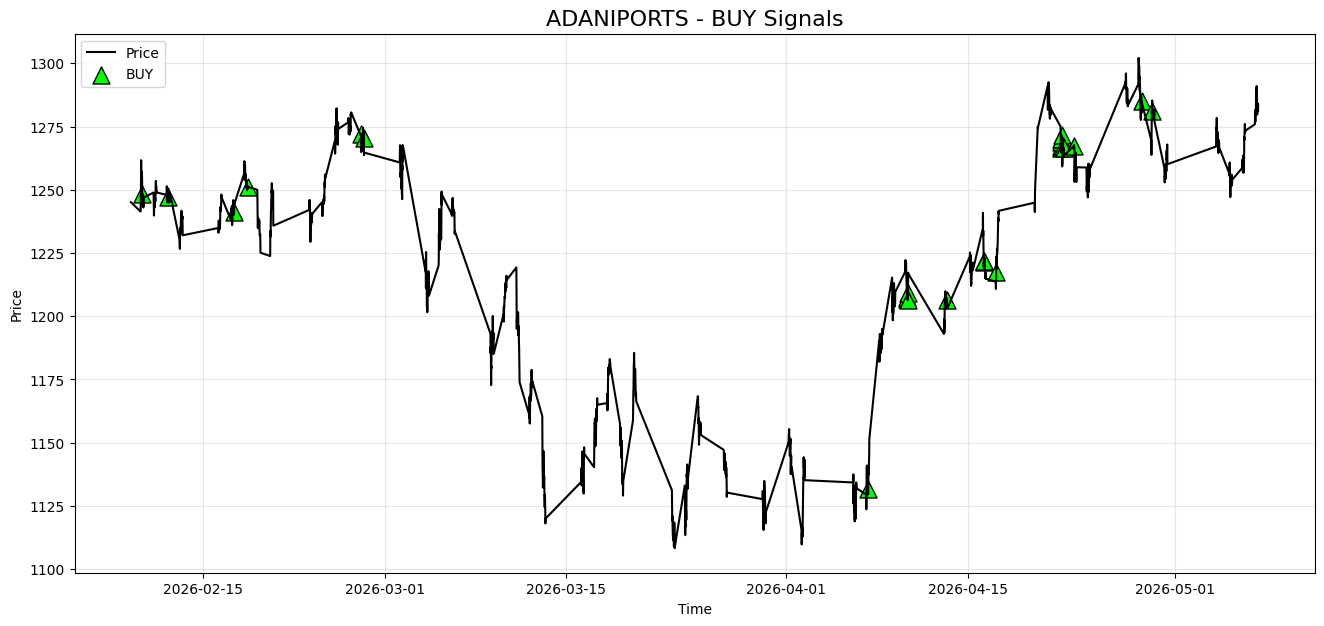

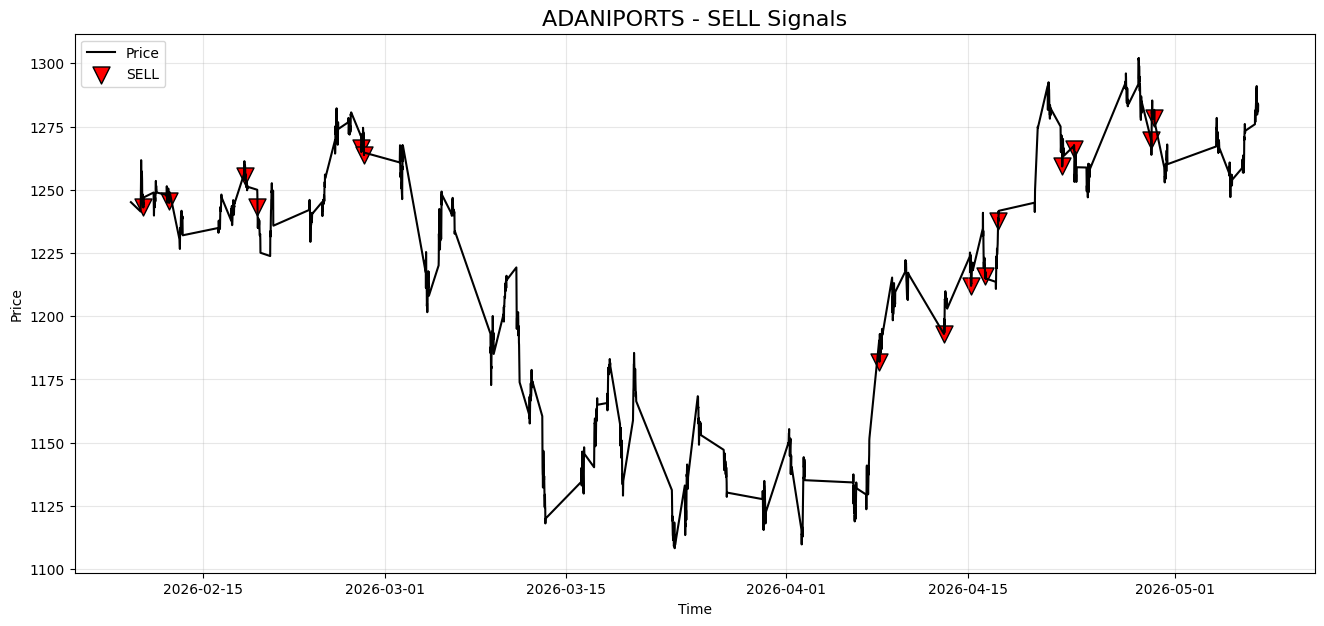

Buy graph saved as:
plots/BUY_20260508_000108.png

Sell graph saved as:
plots/SELL_20260508_000108.png


In [12]:
import matplotlib.pyplot as plt
import os
from datetime import datetime

# =========================
# AUTO FILE NAMES
# =========================

os.makedirs("plots", exist_ok=True)

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

buy_filename = (
    f"plots/BUY_{timestamp}.png"
)

sell_filename = (
    f"plots/SELL_{timestamp}.png"
)

# =========================
# STOCK NAME
# =========================

stock = "ADANIPORTS"

# =========================
# BUY GRAPH
# =========================

plt.figure(figsize=(16,7))

# Price line
plt.plot(
    data.index,
    data["Close"],
    color="black",
    linewidth=1.5,
    label="Price"
)

# BUY signals
buy_signals = data[data["Signal"] == "BUY"]

plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    color="lime",
    marker="^",
    s=150,
    edgecolors="black",
    label="BUY"
)

plt.title(f"{stock} - BUY Signals", fontsize=16)

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.grid(alpha=0.3)

# SAVE BUY GRAPH
plt.savefig(
    buy_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================
# SELL GRAPH
# =========================

plt.figure(figsize=(16,7))

# Price line
plt.plot(
    data.index,
    data["Close"],
    color="black",
    linewidth=1.5,
    label="Price"
)

# SELL signal tracking
sell_indices = []

capital = 100000
holding = False
entry_price = 0
hold_bars = 0

for i in range(len(data)):

    row = data.iloc[i]

    # BUY
    if row["Signal"] == "BUY" and not holding:

        entry_price = row["Close"]

        holding = True

        hold_bars = 0

    # HOLD
    if holding:

        hold_bars += 1

        current_price = row["Close"]

        profit_pct = (
            current_price - entry_price
        ) / entry_price

        if (

            profit_pct <= -0.004
            or
            hold_bars >= 15

        ):

            sell_indices.append(i)

            holding = False

# SELL markers
if sell_indices:

    sell_times = data.index[sell_indices]

    sell_prices = data["Close"].iloc[sell_indices]

    plt.scatter(
        sell_times,
        sell_prices,
        color="red",
        marker="v",
        s=150,
        edgecolors="black",
        label="SELL"
    )

plt.title(f"{stock} - SELL Signals", fontsize=16)

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.grid(alpha=0.3)

# SAVE SELL GRAPH
plt.savefig(
    sell_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Buy graph saved as:")
print(buy_filename)

print("\nSell graph saved as:")
print(sell_filename)

## Step 5: Backtesting the Strategy

Backtesting means testing our strategy on past data.

We simulate:
- Starting capital = ₹100,000  
- Buy when signal = BUY  
- Sell when signal = SELL  

We track:
- Profit from each trade  
- Total number of trades  
- Final capital  

This helps us understand if our strategy would have worked in the past.

Important:
This is only a simulation — real markets may behave differently.

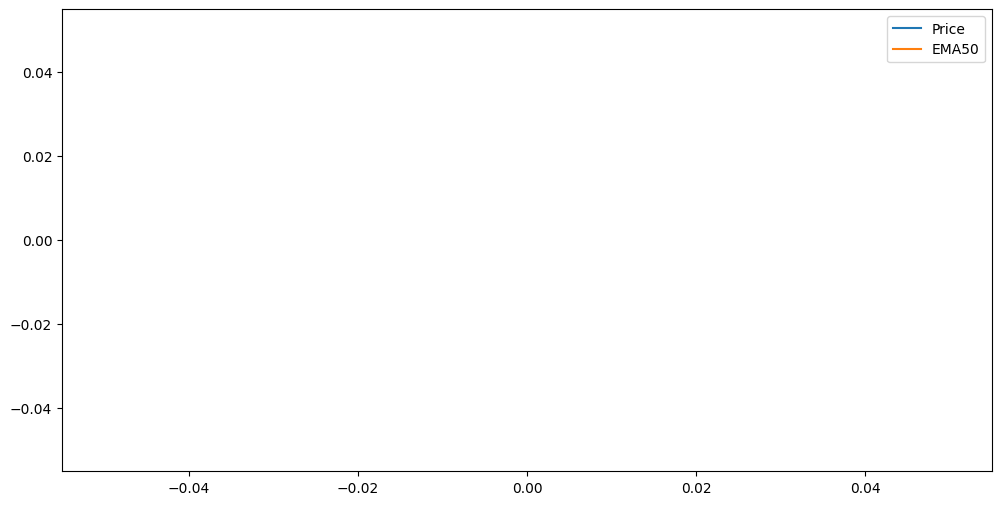

In [68]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Price")
plt.plot(data["EMA50"], label="EMA50")
plt.legend()
plt.show()

## Step 6: Visualizing the Data

We plot:
- Stock price  
- EMA (trend line)

This helps us visually understand:
- Market trend  
- Whether our signals match real price movement  

Visualization is important for debugging and improving the model.